# Notebook 11 — Supervised Contrastive FSL (SupCon)

**Method:** Chen et al., *Supervised Contrastive Few-Shot Learning for  
High-Frequency Time Series*, AAAI 2023

**Core idea:**  
Train the backbone with a supervised contrastive loss that:
- Pulls same-class embeddings together (inter-user consistency)
- Pushes different-class embeddings apart (class discriminability)
- Induces intra-class spread to prevent class collapse  
  (crucial for HAR where same activity looks different across users)

**Key difference from ProtoNet and MAML:**  
Training is NOT episodic — SupCon trains on full batches with class labels,  
not N-way K-shot episodes. The few-shot structure is only used at evaluation.

**Loss function:**
```
L_supcon = supervised contrastive loss (Khosla et al. 2020)
         = for each anchor i, pull all positives (same class) closer
           and push all negatives (different class) away

L_spread  = intra-class spread regularizer (Chen et al. 2023)
          = encourages variance within each class embedding cluster
          = prevents all same-class embeddings collapsing to one point

L_total   = L_supcon + α * L_spread
```

**Pipeline:**
```
Pre-trained backbone + projection head
    ↓
Contrastive training on train users (batch-based, not episodic)
    ↓
Remove projection head — use backbone embedding directly
    ↓
Evaluation:
  A) Generalization  — episodic nearest-prototype on test users
  B) Personalization — K-shot user prototypes → classify remainder
```

---
**Requires:** notebook 00, preprocessing notebook, backbone checkpoint.

## Cell 1 — Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

%run "/content/drive/MyDrive/Colab Notebooks/00_config_and_utils.ipynb"

DATASET_NAME   = 'wisdm'
BACKBONE_TYPE  = 'cnn'    # 'cnn' | 'lstm' | 'transformer'

# SupCon hyperparameters
SUPCON_TEMP      = 0.07    # temperature τ — lower = sharper contrastive boundary
SUPCON_ALPHA     = 0.5     # weight of spread loss
PROJ_DIM         = 64      # projection head output dimension
SUPCON_EPOCHS    = FSL_EPOCHS

print(f'\n✅ Setup complete')
print(f'   Method        : Supervised Contrastive FSL')
print(f'   Dataset       : {DATASET_NAME}')
print(f'   Backbone      : {BACKBONE_TYPE}')
print(f'   Temperature τ : {SUPCON_TEMP}')
print(f'   Spread α      : {SUPCON_ALPHA}')
print(f'   Proj dim      : {PROJ_DIM}')
print(f'   Device        : {DEVICE}')

Mounted at /content/drive
✅ Imports OK
   PyTorch  : 2.10.0+cu128
   NumPy    : 2.0.2
   CUDA     : True
   GPU      : Tesla T4
✅ Seeded everything with MASTER_SEED=42
✅ Global hyperparameters set
   Target frequency : 50 Hz
   Window size      : 250 samples (5.0 sec)
   Window stride    : 125 samples (2.5 sec)
   K shots          : [1, 5, 10]
   N way (default)  : 5
   Embedding dim    : 128
   Device           : cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths configured
   Processed data  → /content/drive/MyDrive/fsl_har_processed
   Checkpoints     → /content/drive/MyDrive/fsl_har_checkpoints
   Results         → /content/drive/MyDrive/fsl_har_results
✅ Dataset configs loaded
   wisdm                  →  51 subjects |  18 classes |  4 streams | n_way=5
   cogage_atomic          →   8 subjects |  61 classes |  9 streams | n_way=5
   cogage_composite       →   6 subjects |   7 classes | 10 st

## Cell 2 — Load Dataset and Backbone

✅ Loaded "wisdm" — 63513 windows | 4 streams
── Dataset: wisdm ──
   Windows : 63,513  |  streams: 4  |  classes: 18
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Imports OK
   PyTorch  : 2.10.0+cu128
   NumPy    : 2.0.2
   CUDA     : True
   GPU      : Tesla T4
✅ Seeded everything with MASTER_SEED=42
✅ Global hyperparameters set
   Target frequency : 50 Hz
   Window size      : 250 samples (5.0 sec)
   Window stride    : 125 samples (2.5 sec)
   K shots          : [1, 5, 10]
   N way (default)  : 5
   Embedding dim    : 128
   Device           : cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths configured
   Processed data  → /content/drive/MyDrive/fsl_har_processed
   Checkpoints     → /content/drive/MyDrive/fsl_har_checkpoints
   Results         → /content/drive/MyDrive/fsl_har_results
✅ Dataset configs loade

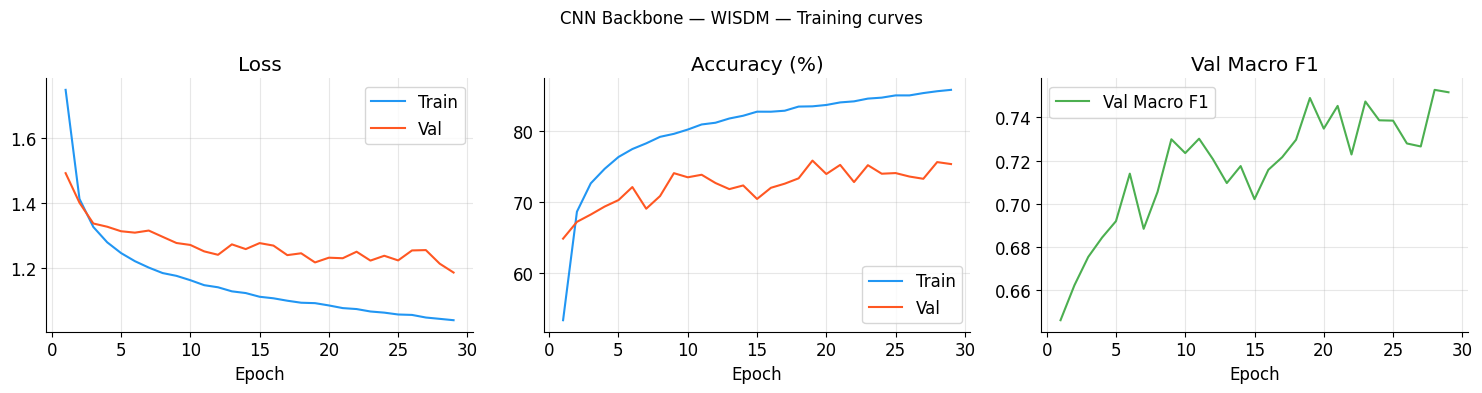

Saved: /content/drive/MyDrive/fsl_har_checkpoints/wisdm/cnn/training_curves.png
Loaded checkpoint from epoch 19
  Checkpoint val acc : 75.78%

── Test set results (unseen users, no adaptation) ──
   Test accuracy  : 69.11%
   Test macro F1  : 0.6766
   Test loss      : 1.3872

   This is the GENERALIZATION baseline.
   FSL methods will improve on this through personalization.

✅ Result saved to registry


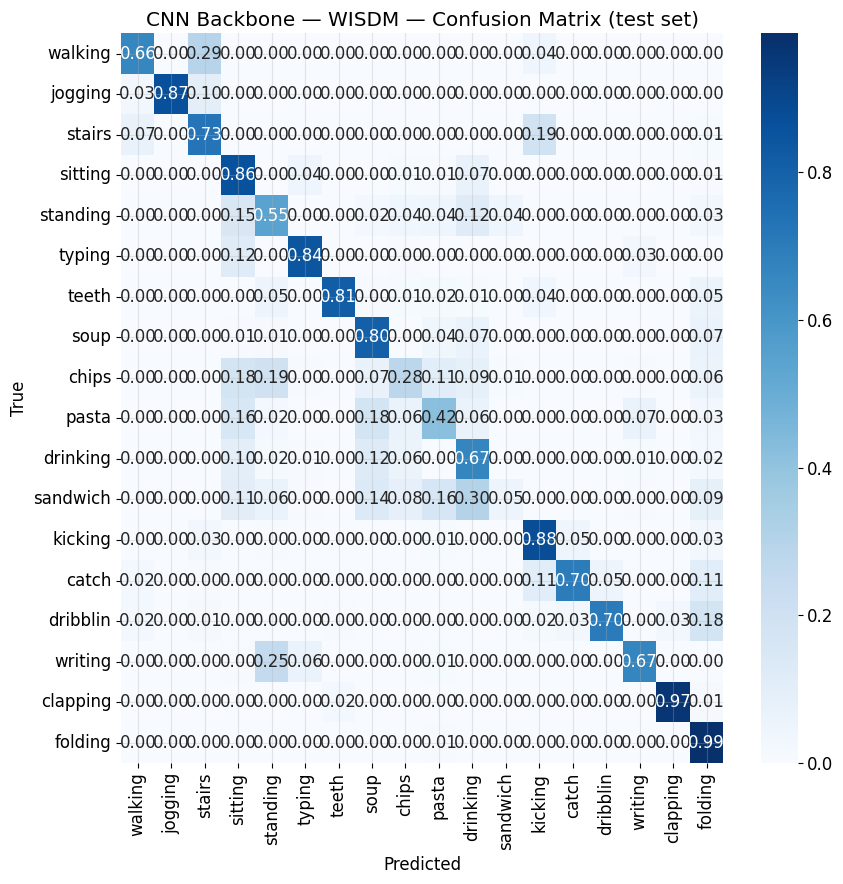

Saved: /content/drive/MyDrive/fsl_har_checkpoints/wisdm/cnn/confusion_matrix.png
Verifying backbone interface for FSL methods...

   n_way=5, k_shot=5
   Support batch size : 25
   Support embeddings : torch.Size([25, 128])
   Expected           : (25, 128)
   Embedding norms    : mean=7.486, std=0.260

✅ Backbone interface verified
   FSL methods can load this backbone with:
   backbone = CNNBackbone(n_streams=4, n_classes=18, ...)
   load_checkpoint(backbone, '/content/drive/MyDrive/fsl_har_checkpoints/wisdm/cnn/best_backbone.pt')
   embeddings = backbone.get_embedding(stream_list)
  CNN BACKBONE TRAINING COMPLETE
  Dataset          : wisdm
  Streams          : 4  (['phone_accel', 'phone_gyro', 'watch_accel', 'watch_gyro'])
  Classes          : 18
  Embedding dim    : 128
  Epochs trained   : 29
  Best val acc     : 75.78%
  Test acc         : 69.11%  ← generalization baseline
  Test macro F1    : 0.6766
  Checkpoint       : /content/drive/MyDrive/fsl_har_checkpoints/wisdm/cnn/best_b

In [ ]:
data = load_processed_dataset(DATASET_NAME)

streams      = data['streams']
y            = data['y']
subject_ids  = data['subject_ids']
stream_names = data['stream_names']
split_info   = data['split_info']
cfg          = data['config']
sam          = data.get('subject_activity_map')

n_streams = len(stream_names)
n_classes = cfg['n_classes']
n_way     = cfg['n_way']
N, T, C   = streams[stream_names[0]].shape

train_mask = get_split_mask(subject_ids, split_info['train'])
val_mask   = get_split_mask(subject_ids, split_info['val'])
test_mask  = get_split_mask(subject_ids, split_info['test'])

print(f'── Dataset: {DATASET_NAME} ──')
print(f'   Windows : {N:,}  |  streams: {n_streams}  |  classes: {n_classes}')

# ─── Load backbone ────────────────────────────────────────────────────────────
ckpt_path = os.path.join(CHECKPOINT_BASE, DATASET_NAME, BACKBONE_TYPE, 'best_backbone.pt')
assert os.path.exists(ckpt_path), f'Backbone not found: {ckpt_path}'

if BACKBONE_TYPE == 'cnn':
    %run "/content/drive/MyDrive/Colab Notebooks/05_train_backbone_cnn.ipynb"
    BackboneClass   = CNNBackbone
    backbone_kwargs = dict(n_streams=n_streams, n_classes=n_classes,
                           in_channels=C, d_stream=64, embedding_dim=EMBEDDING_DIM)
elif BACKBONE_TYPE == 'lstm':
    %run "/content/drive/MyDrive/Colab Notebooks/06_train_backbone_lstm.ipynb"
    BackboneClass   = LSTMBackbone
    backbone_kwargs = dict(n_streams=n_streams, n_classes=n_classes,
                           input_size=C, hidden_size=64, num_layers=2,
                           dropout=0.3, embedding_dim=EMBEDDING_DIM)
elif BACKBONE_TYPE == 'transformer':
    %run "/content/drive/MyDrive/Colab Notebooks/07_train_backbone_transformer.ipynb"
    BackboneClass   = TransformerBackbone
    backbone_kwargs = dict(n_streams=n_streams, n_classes=n_classes,
                           in_channels=C, d_model=64, nhead=4, num_layers=2,
                           dim_feedforward=256, dropout=0.1, embedding_dim=EMBEDDING_DIM)

backbone = BackboneClass(**backbone_kwargs).to(DEVICE)
meta     = load_checkpoint(backbone, ckpt_path)

print(f'\n── Backbone: {BACKBONE_TYPE} ──')
print(f'   Loaded from epoch : {meta.get("epoch", "?")}')
print(f'   Pretrain val acc  : {meta.get("val_acc", 0)*100:.2f}%')

## Cell 3 — SupCon Model with Projection Head

A projection head is appended to the backbone during contrastive training.  
Following SimCLR and SupCon best practice, the projection head is a  
2-layer MLP: `embedding_dim → hidden → proj_dim`.  
The projection head is **removed after training** — evaluation uses  
the backbone embedding directly (this is standard in contrastive learning).

In [ ]:
class SupConModel(nn.Module):
    """
    Backbone + projection head for supervised contrastive training.

    The projection head maps backbone embeddings to a lower-dimensional
    space where the contrastive loss is computed.
    After training, only the backbone is used for evaluation.
    """

    def __init__(
        self,
        backbone   : nn.Module,
        embed_dim  : int = EMBEDDING_DIM,
        proj_dim   : int = PROJ_DIM,
        hidden_dim : int = 128,
    ):
        super().__init__()
        self.backbone = backbone

        # 2-layer MLP projection head
        self.projector = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, proj_dim),
        )

    def forward(
        self,
        stream_list   : List[torch.Tensor],
        project       : bool = True,
    ) -> torch.Tensor:
        """
        Args:
            stream_list : list of n_streams tensors (batch, T, C)
            project     : if True, return projected embeddings (for training)
                          if False, return backbone embeddings (for evaluation)
        Returns:
            (batch, proj_dim) if project=True
            (batch, embed_dim) if project=False
        """
        embedding = self.backbone.get_embedding(stream_list)   # (batch, embed_dim)
        if project:
            return self.projector(embedding)                    # (batch, proj_dim)
        return embedding

    def get_embedding(self, stream_list: List[torch.Tensor]) -> torch.Tensor:
        """FSL interface — returns backbone embedding without projection."""
        return self.forward(stream_list, project=False)


supcon_model = SupConModel(
    backbone  = backbone,
    embed_dim = EMBEDDING_DIM,
    proj_dim  = PROJ_DIM,
).to(DEVICE)

n_params = sum(p.numel() for p in supcon_model.parameters() if p.requires_grad)
print(f'✅ SupConModel created')
print(f'   Backbone params  : {sum(p.numel() for p in backbone.parameters()):,}')
print(f'   Projector params : {sum(p.numel() for p in supcon_model.projector.parameters()):,}')
print(f'   Total params     : {n_params:,}')
print(f'   Projection dim   : {EMBEDDING_DIM} → 128 → {PROJ_DIM}')

✅ SupConModel created
   Backbone params  : 129,938
   Projector params : 24,768
   Total params     : 154,706
   Projection dim   : 128 → 128 → 64


## Cell 4 — Supervised Contrastive Loss with Spread Term

Implementation of Chen et al. (AAAI 2023) loss:

**Standard SupCon loss** (Khosla et al. 2020):  
For each anchor `i`, positive set `P(i)` = all same-class samples in batch:
```
L_i = -1/|P(i)| * Σ_{p∈P(i)} log[ exp(z_i·z_p/τ) / Σ_{a≠i} exp(z_i·z_a/τ) ]
```

**Spread term** (Chen et al. 2023 addition):  
Penalizes low within-class variance to prevent collapse:
```
L_spread = -mean_over_classes( variance of embeddings within class )
```

In [ ]:
class SupervisedContrastiveLoss(nn.Module):
    """
    Supervised Contrastive Loss with intra-class spread regularizer.
    From Chen et al. (AAAI 2023) adapted for HAR time-series.

    L_total = L_supcon + alpha * L_spread
    """

    def __init__(
        self,
        temperature : float = SUPCON_TEMP,
        alpha       : float = SUPCON_ALPHA,
    ):
        super().__init__()
        self.temperature = temperature
        self.alpha       = alpha

    def forward(
        self,
        features : torch.Tensor,
        labels   : torch.Tensor,
    ) -> Tuple[torch.Tensor, Dict]:
        """
        Args:
            features : (batch, proj_dim) — L2-normalised projected embeddings
            labels   : (batch,) integer class labels

        Returns:
            total_loss : scalar
            breakdown  : dict with 'supcon', 'spread', 'total' values
        """
        batch_size = features.shape[0]
        device     = features.device

        # L2 normalise for cosine similarity via dot product
        features = nn.functional.normalize(features, dim=-1)

        # ── Standard Supervised Contrastive Loss ──────────────────────────────
        # Pairwise cosine similarity matrix (batch, batch)
        sim_matrix = torch.matmul(features, features.T) / self.temperature

        # Mask: True where i ≠ j
        mask_not_self = ~torch.eye(batch_size, dtype=torch.bool, device=device)

        # Positive mask: same class AND i ≠ j
        labels_col = labels.unsqueeze(1)   # (batch, 1)
        labels_row = labels.unsqueeze(0)   # (1, batch)
        mask_pos   = (labels_col == labels_row) & mask_not_self   # (batch, batch)

        # Check that every anchor has at least one positive
        n_pos = mask_pos.sum(dim=1)   # (batch,)
        valid = n_pos > 0

        if valid.sum() == 0:
            # No valid anchors (can happen with small batches + many classes)
            return torch.tensor(0.0, device=device, requires_grad=True), \
                   {'supcon': 0.0, 'spread': 0.0, 'total': 0.0}

        # For numerical stability: subtract max before exp
        sim_max, _ = sim_matrix.max(dim=1, keepdim=True)
        sim_matrix = sim_matrix - sim_max.detach()

        # Denominator: sum over all j ≠ i
        exp_sim   = torch.exp(sim_matrix) * mask_not_self.float()
        log_denom = torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-9)   # (batch, 1)

        # Numerator: sum over positives
        log_prob    = sim_matrix - log_denom   # (batch, batch)
        mean_log_prob_pos = (
            (mask_pos.float() * log_prob).sum(dim=1)
            / (n_pos.float() + 1e-9)
        )   # (batch,)

        # SupCon loss: mean over valid anchors
        loss_supcon = -mean_log_prob_pos[valid].mean()

        # ── Intra-class Spread Loss ────────────────────────────────────────────
        # For each class: compute variance of embeddings within that class
        # Minimize NEGATIVE variance = maximize spread
        unique_classes = labels.unique()
        spread_terms   = []

        for c in unique_classes:
            class_mask = (labels == c)
            if class_mask.sum() < 2:
                continue   # need at least 2 samples to compute variance
            class_feats = features[class_mask]   # (n_c, proj_dim)
            # Variance across embedding dimensions, averaged
            class_var   = class_feats.var(dim=0).mean()   # scalar
            spread_terms.append(class_var)

        if spread_terms:
            mean_spread  = torch.stack(spread_terms).mean()
            loss_spread  = -mean_spread   # negative because we want to MAXIMISE spread
        else:
            loss_spread  = torch.tensor(0.0, device=device)

        # ── Total loss ────────────────────────────────────────────────────────
        loss_total = loss_supcon + self.alpha * loss_spread

        return loss_total, {
            'supcon' : loss_supcon.item(),
            'spread' : loss_spread.item(),
            'total'  : loss_total.item(),
        }


# ─── Quick verification ───────────────────────────────────────────────────────
print('Testing SupCon loss...')
criterion_supcon = SupervisedContrastiveLoss(temperature=SUPCON_TEMP, alpha=SUPCON_ALPHA)

_batch  = 32
_feats  = torch.randn(_batch, PROJ_DIM)
_labels = torch.arange(n_way).repeat(_batch // n_way + 1)[:_batch]

_loss, _breakdown = criterion_supcon(_feats, _labels)
print(f'   Batch size : {_batch}')
print(f'   SupCon loss: {_breakdown["supcon"]:.4f}')
print(f'   Spread loss: {_breakdown["spread"]:.4f}')
print(f'   Total loss : {_breakdown["total"]:.4f}')
assert not torch.isnan(_loss), 'NaN in loss'

del _feats, _labels, _loss, _breakdown
print('\n✅ SupCon loss verified')

Testing SupCon loss...
   Batch size : 32
   SupCon loss: 4.8802
   Spread loss: -0.0159
   Total loss : 4.8722

✅ SupCon loss verified


## Cell 5 — DataLoader for Contrastive Training

SupCon training is batch-based, not episodic.  
We need batches that contain multiple samples per class  
so the contrastive loss has positive pairs to work with.

**Class-balanced batch sampler:** ensures each batch contains  
at least `n_samples_per_class` samples from each class.

In [ ]:
class ClassBalancedSampler(torch.utils.data.Sampler):
    """
    Samples batches with at least min_samples_per_class per class.
    Ensures contrastive loss always has positive pairs.
    """

    def __init__(
        self,
        labels               : np.ndarray,
        batch_size           : int,
        min_samples_per_class: int = 4,
        n_batches            : int = None,
        seed                 : int = MASTER_SEED,
    ):
        self.labels                = labels
        self.batch_size            = batch_size
        self.min_spc               = min_samples_per_class
        self.rng                   = np.random.default_rng(seed)

        # Index per class
        self.class_indices = {
            c: np.where(labels == c)[0]
            for c in np.unique(labels)
        }
        self.classes = list(self.class_indices.keys())
        self.n_batches = n_batches or (len(labels) // batch_size)

    def __iter__(self):
        for _ in range(self.n_batches):
            batch_idx = []
            # Sample min_samples_per_class from each class
            for c in self.classes:
                c_idx = self.class_indices[c]
                sampled = self.rng.choice(
                    c_idx,
                    size=min(self.min_spc, len(c_idx)),
                    replace=len(c_idx) < self.min_spc
                )
                batch_idx.extend(sampled.tolist())

            # If batch is smaller than batch_size, fill with random samples
            if len(batch_idx) < self.batch_size:
                extra = self.rng.choice(
                    len(self.labels),
                    size=self.batch_size - len(batch_idx),
                    replace=False
                )
                batch_idx.extend(extra.tolist())

            # Shuffle and yield batch_size indices
            self.rng.shuffle(batch_idx)
            yield batch_idx[:self.batch_size]

    def __len__(self):
        return self.n_batches


# ─── Build DataLoaders ────────────────────────────────────────────────────────
train_dataset = MultiStreamDataset(streams, y, stream_names, train_mask)
val_dataset   = MultiStreamDataset(streams, y, stream_names, val_mask)

# Larger batch for contrastive training — more negatives = better gradients
SUPCON_BATCH = min(128, train_mask.sum())

train_sampler_cb = ClassBalancedSampler(
    labels                = y[train_mask],
    batch_size            = SUPCON_BATCH,
    min_samples_per_class = max(2, SUPCON_BATCH // n_classes),
    n_batches             = N_EPISODES_TRAIN,   # batches per epoch
)

train_loader_sc = torch.utils.data.DataLoader(
    train_dataset,
    batch_sampler = train_sampler_cb,
    collate_fn    = multistream_collate,
    num_workers   = 0,
    pin_memory    = True if DEVICE.type == 'cuda' else False,
)
val_loader_sc = torch.utils.data.DataLoader(
    val_dataset,
    batch_size  = SUPCON_BATCH,
    shuffle     = False,
    collate_fn  = multistream_collate,
    num_workers = 0,
)

print(f'✅ DataLoaders ready')
print(f'   Batch size         : {SUPCON_BATCH}')
print(f'   Min samples/class  : {max(2, SUPCON_BATCH // n_classes)}')
print(f'   Train batches/epoch: {len(train_loader_sc)}')

✅ DataLoaders ready
   Batch size         : 128
   Min samples/class  : 7
   Train batches/epoch: 300


## Cell 6 — Contrastive Training Loop

Trains backbone + projection head with SupCon loss.  
Val loss is also contrastive (not classification) — measures embedding quality.

In [ ]:
optimizer = torch.optim.Adam(
    supcon_model.parameters(),
    lr           = LEARNING_RATE,
    weight_decay = 1e-4,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=SUPCON_EPOCHS, eta_min=1e-5
)

fsl_ckpt_dir  = os.path.join(CHECKPOINT_BASE, DATASET_NAME, BACKBONE_TYPE, 'supcon')
os.makedirs(fsl_ckpt_dir, exist_ok=True)
fsl_ckpt_path = os.path.join(fsl_ckpt_dir, 'best_supcon.pt')

PATIENCE       = 15
best_val_loss  = float('inf')   # SupCon: lower val loss = better
patience_count = 0
epochs_ran     = 0

history = {
    'train_loss':[], 'train_supcon':[], 'train_spread':[],
    'val_loss':  [],
}

print(f'Contrastive training: SupCon on {DATASET_NAME} / {BACKBONE_TYPE}')
print(f'  τ={SUPCON_TEMP}  α={SUPCON_ALPHA}  proj_dim={PROJ_DIM}')
print(f'  Batch size: {SUPCON_BATCH}  |  LR: {LEARNING_RATE}')
print(f'  Note: monitoring VAL LOSS (lower = better embedding space)')
print(f'{"─"*70}')
print(f'{"Epoch":>5} {"TrLoss":>9} {"SupCon":>9} {"Spread":>9} {"VlLoss":>9}')
print(f'{"─"*70}')

for epoch in range(1, SUPCON_EPOCHS + 1):
    # ── Train epoch ───────────────────────────────────────────────────────────
    supcon_model.train()
    tr_loss_sum = 0.0
    tr_sc_sum   = 0.0
    tr_sp_sum   = 0.0
    n_batches   = 0

    for stream_list, labels in train_loader_sc:
        stream_list = [s.to(DEVICE) for s in stream_list]
        labels      = labels.to(DEVICE)

        # Project embeddings for contrastive loss
        proj  = supcon_model(stream_list, project=True)
        loss, breakdown = criterion_supcon(proj, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(supcon_model.parameters(), max_norm=1.0)
        optimizer.step()

        tr_loss_sum += breakdown['total']
        tr_sc_sum   += breakdown['supcon']
        tr_sp_sum   += breakdown['spread']
        n_batches   += 1

    tr_loss = tr_loss_sum / max(n_batches, 1)
    tr_sc   = tr_sc_sum   / max(n_batches, 1)
    tr_sp   = tr_sp_sum   / max(n_batches, 1)

    # ── Val epoch ─────────────────────────────────────────────────────────────
    supcon_model.eval()
    vl_loss_sum = 0.0
    n_val_batches = 0

    with torch.no_grad():
        for stream_list, labels in val_loader_sc:
            stream_list = [s.to(DEVICE) for s in stream_list]
            labels      = labels.to(DEVICE)
            proj        = supcon_model(stream_list, project=True)
            _, breakdown = criterion_supcon(proj, labels)
            vl_loss_sum += breakdown['total']
            n_val_batches += 1

    vl_loss = vl_loss_sum / max(n_val_batches, 1)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_supcon'].append(tr_sc)
    history['train_spread'].append(tr_sp)
    history['val_loss'].append(vl_loss)
    epochs_ran += 1

    improved = vl_loss < best_val_loss
    if improved:
        best_val_loss  = vl_loss
        patience_count = 0
        save_checkpoint(
            supcon_model.backbone, fsl_ckpt_path,
            extra={
                'epoch'       : epoch,
                'val_loss'    : vl_loss,
                'dataset'     : DATASET_NAME,
                'backbone'    : BACKBONE_TYPE,
                'method'      : 'supcon',
                'temperature' : SUPCON_TEMP,
                'alpha'       : SUPCON_ALPHA,
            }
        )
    else:
        patience_count += 1

    marker = ' ✅' if improved else ''
    print(f'{epoch:>5} {tr_loss:>9.4f} {tr_sc:>9.4f} {tr_sp:>9.4f} '
          f'{vl_loss:>9.4f}{marker}')

    if patience_count >= PATIENCE:
        print(f'\n   Early stopping at epoch {epoch}')
        break

print(f'\n{"─"*70}')
print(f'✅ Contrastive training complete — best val loss: {best_val_loss:.4f}')

Contrastive training: SupCon on wisdm / cnn
  τ=0.07  α=0.5  proj_dim=64
  Batch size: 128  |  LR: 0.0003
  Note: monitoring VAL LOSS (lower = better embedding space)
──────────────────────────────────────────────────────────────────────
Epoch    TrLoss    SupCon    Spread    VlLoss
──────────────────────────────────────────────────────────────────────
    1    3.0051    3.0066   -0.0030    4.1551 ✅
    2    2.6609    2.6620   -0.0021    4.1591
    3    2.5468    2.5477   -0.0018    4.1911
    4    2.4858    2.4866   -0.0016    4.1715
    5    2.4294    2.4302   -0.0015    4.1980
    6    2.4112    2.4119   -0.0014    4.2031
    7    2.3792    2.3798   -0.0013    4.2229
    8    2.3605    2.3611   -0.0012    4.2197
    9    2.3381    2.3387   -0.0011    4.2506
   10    2.3181    2.3186   -0.0011    4.2558
   11    2.3109    2.3114   -0.0011    4.2598
   12    2.2780    2.2785   -0.0010    4.2381
   13    2.2781    2.2785   -0.0010    4.2811
   14    2.2652    2.2657   -0.0010    4.2334

## Cell 7 — Training Curves

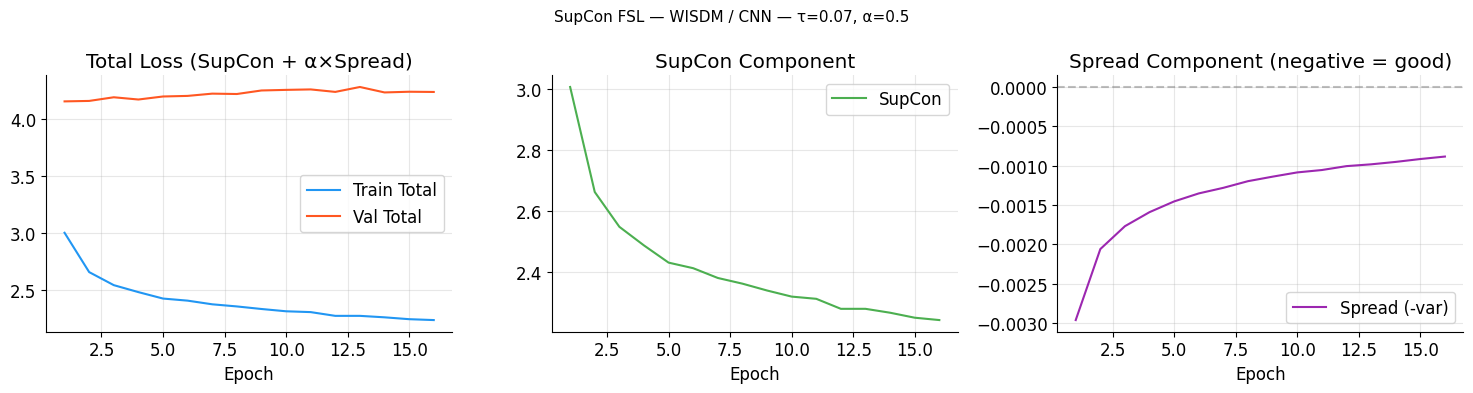

In [ ]:
ep = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ep, history['train_loss'], label='Train Total', color='#2196F3')
axes[0].plot(ep, history['val_loss'],   label='Val Total',   color='#FF5722')
axes[0].set_title('Total Loss (SupCon + α×Spread)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(ep, history['train_supcon'], label='SupCon', color='#4CAF50')
axes[1].set_title('SupCon Component')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# Spread loss — should be negative (we're maximising spread)
axes[2].plot(ep, history['train_spread'], label='Spread (-var)', color='#9C27B0')
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('Spread Component (negative = good)')
axes[2].set_xlabel('Epoch')
axes[2].legend()

fig.suptitle(
    f'SupCon FSL — {DATASET_NAME.upper()} / {BACKBONE_TYPE.upper()} — '
    f'τ={SUPCON_TEMP}, α={SUPCON_ALPHA}',
    fontsize=11
)
plt.tight_layout()
plt.savefig(os.path.join(fsl_ckpt_dir, 'training_curves.png'), dpi=120)
plt.show()

## Cell 8 — Load Best Backbone and Episode Sampler

After contrastive training, the projection head is discarded.  
Evaluation uses the backbone embedding directly.

In [ ]:
# Load best backbone (saved without projection head)
best_backbone = BackboneClass(**backbone_kwargs).to(DEVICE)
ckpt_info     = load_checkpoint(best_backbone, fsl_ckpt_path)
best_backbone.eval()

print(f'✅ Best SupCon backbone loaded (epoch {ckpt_info.get("epoch","?")})')
print(f'   Val contrastive loss at save: {ckpt_info.get("val_loss", 0):.4f}')
print(f'   Projection head discarded — using backbone embedding directly')

# Force string conversion — same fix as notebook 10
sub_ids_str = subject_ids.astype(str)
val_split   = [str(s) for s in split_info['val']]
test_split  = [str(s) for s in split_info['test']]

val_sampler = EpisodeSampler(
    stream_arrays        = streams,
    y                    = y,
    subject_ids          = sub_ids_str,    # ← string version
    subject_split        = val_split,      # ← string version
    n_way                = n_way,
    n_query              = N_QUERY,
    subject_activity_map = sam,
    seed                 = MASTER_SEED + 1,
)
test_sampler = EpisodeSampler(
    stream_arrays        = streams,
    y                    = y,
    subject_ids          = sub_ids_str,    # ← string version
    subject_split        = test_split,     # ← string version
    n_way                = n_way,
    n_query              = N_QUERY,
    subject_activity_map = sam,
    seed                 = MASTER_SEED + 2,
)
print(f'\n✅ Episode samplers ready')
print(f'   Val   classes available : {len(val_sampler.available_classes)}')
print(f'   Test  classes available : {len(test_sampler.available_classes)}')

✅ Best SupCon backbone loaded (epoch 1)
   Val contrastive loss at save: 4.1551
   Projection head discarded — using backbone embedding directly

✅ Episode samplers ready
   Val   classes available : 18
   Test  classes available : 18


## Cell 9 — Generalization Evaluation

Episodic nearest-prototype evaluation on test users.  
No adaptation — purely tests embedding space quality.

In [ ]:
@torch.no_grad()
def evaluate_generalization_supcon(
    backbone   : nn.Module,
    sampler    : EpisodeSampler,
    k_shot     : int,
    n_episodes : int = N_EPISODES_EVAL,
) -> Dict:
    """Episodic nearest-prototype generalization evaluation."""
    backbone.eval()
    episode_accs = []

    for _ in range(n_episodes):
        episode  = sampler.sample_episode(k_shot=k_shot)
        sup_list = [episode['support_streams'][s].to(DEVICE) for s in stream_names]
        qry_list = [episode['query_streams'][s].to(DEVICE)   for s in stream_names]
        sup_lab  = episode['support_labels'].to(DEVICE)
        qry_lab  = episode['query_labels'].to(DEVICE)

        sup_emb  = backbone.get_embedding(sup_list)
        qry_emb  = backbone.get_embedding(qry_list)

        # Compute prototypes
        prototypes = torch.zeros(sampler.n_way, EMBEDDING_DIM, device=DEVICE)
        for c in range(sampler.n_way):
            mask = (sup_lab == c)
            if mask.any():
                prototypes[c] = sup_emb[mask].mean(dim=0)

        # Nearest prototype classification
        diff  = qry_emb.unsqueeze(1) - prototypes.unsqueeze(0)
        dists = (diff ** 2).sum(dim=-1)
        preds = dists.argmin(dim=-1)
        acc   = (preds == qry_lab).float().mean().item()
        episode_accs.append(acc)

    accs = np.array(episode_accs)
    ci95 = 1.96 * accs.std() / np.sqrt(len(accs))
    return {'acc_mean': float(accs.mean()), 'acc_std': float(accs.std()), 'ci95': float(ci95)}


print('── Generalization Evaluation (test users, episodic) ──')
print(f'{"K-shot":>8} {"Acc Mean":>12} {"±CI95":>10}')
print('─' * 34)

gen_results = {}
for k in K_SHOTS:
    res = evaluate_generalization_supcon(best_backbone, test_sampler, k_shot=k)
    gen_results[k] = res
    print(f'{k:>8}-shot {res["acc_mean"]*100:>10.2f}% ±{res["ci95"]*100:>7.2f}%')

── Generalization Evaluation (test users, episodic) ──
  K-shot     Acc Mean      ±CI95
──────────────────────────────────
       1-shot      75.14% ±   1.61%
       5-shot      84.71% ±   1.39%
      10-shot      85.78% ±   1.16%


## Cell 10 — Personalization Evaluation

SupCon personalization: K-shot support from test user → compute user-specific  
prototypes using the contrastively trained backbone → classify remainder.

No fine-tuning at test time — the embedding space learned during contrastive  
training is used directly. The quality of that space is what determines gain.

In [ ]:
# ─── Fix: use string-converted IDs throughout ─────────────────────────────────
sub_ids_str   = subject_ids.astype(str)
train_subjects_str = [str(s) for s in split_info['train']]
test_subjects      = [str(s) for s in split_info['test']]

@torch.no_grad()
def supcon_personalize_one_user(
    backbone     : nn.Module,
    user_streams : Dict[str, np.ndarray],
    user_y       : np.ndarray,
    k_shot       : int,
    n_trials     : int = 10,
    seed         : int = MASTER_SEED,
) -> Optional[Dict]:
    backbone.eval()
    rng           = np.random.default_rng(seed)
    classes       = np.unique(user_y)
    valid_classes = [c for c in classes if (user_y == c).sum() > k_shot]

    if len(valid_classes) < 2:
        return None

    n_ep_way     = len(valid_classes)
    class_to_rel = {c: i for i, c in enumerate(valid_classes)}

    trial_accs_before = []
    trial_accs_after  = []

    for _ in range(n_trials):
        support_idx = []
        query_idx   = []
        for c in valid_classes:
            c_idx = np.where(user_y == c)[0]
            rng.shuffle(c_idx)
            support_idx.extend(c_idx[:k_shot].tolist())
            query_idx.extend(c_idx[k_shot:].tolist())

        if not query_idx:
            continue

        sup_labels_rel = torch.tensor(
            [class_to_rel[user_y[i]] for i in support_idx], dtype=torch.long
        ).to(DEVICE)
        qry_labels_rel = torch.tensor(
            [class_to_rel[user_y[i]] for i in query_idx], dtype=torch.long
        ).to(DEVICE)

        sup_list = [
            torch.tensor(user_streams[s][support_idx], dtype=torch.float32).to(DEVICE)
            for s in stream_names
        ]
        qry_list = [
            torch.tensor(user_streams[s][query_idx], dtype=torch.float32).to(DEVICE)
            for s in stream_names
        ]

        sup_emb = backbone.get_embedding(sup_list)
        qry_emb = backbone.get_embedding(qry_list)

        # ── Acc BEFORE: global prototypes ─────────────────────────────────────
        valid_global = global_prototypes[list(valid_classes)]
        diff_before  = qry_emb.unsqueeze(1) - valid_global.unsqueeze(0)
        dists_before = (diff_before ** 2).sum(dim=-1)
        preds_before = dists_before.argmin(dim=-1)
        acc_before   = (preds_before == qry_labels_rel).float().mean().item()
        trial_accs_before.append(acc_before)

        # ── Acc AFTER: user-specific K-shot prototypes ─────────────────────────
        user_protos = torch.zeros(n_ep_way, EMBEDDING_DIM, device=DEVICE)
        for c_idx in range(n_ep_way):
            mask = (sup_labels_rel == c_idx)
            if mask.any():
                user_protos[c_idx] = sup_emb[mask].mean(dim=0)

        diff_after  = qry_emb.unsqueeze(1) - user_protos.unsqueeze(0)
        dists_after = (diff_after ** 2).sum(dim=-1)
        preds_after = dists_after.argmin(dim=-1)
        acc_after   = (preds_after == qry_labels_rel).float().mean().item()
        trial_accs_after.append(acc_after)

    if not trial_accs_after:
        return None

    ab = float(np.mean(trial_accs_before))
    aa = float(np.mean(trial_accs_after))
    return {
        'acc_before_mean' : ab,
        'acc_after_mean'  : aa,
        'gain'            : compute_personalization_gain(ab, aa),
        'acc_before_std'  : float(np.std(trial_accs_before)),
        'acc_after_std'   : float(np.std(trial_accs_after)),
        'n_trials'        : len(trial_accs_after),
        'n_valid_classes' : n_ep_way,
    }


# ─── Build global prototypes ──────────────────────────────────────────────────
print('Building global prototypes from SupCon backbone...')

@torch.no_grad()
def _build_global_prototypes_supcon(backbone, streams, y, subject_ids_str,
                                     train_subjects_str, n_classes, batch_size=256):
    backbone.eval()
    train_mask   = get_split_mask(subject_ids_str, train_subjects_str)  # ← string args
    proto_sums   = torch.zeros(n_classes, EMBEDDING_DIM, device=DEVICE)
    proto_counts = torch.zeros(n_classes, device=DEVICE)
    indices      = np.where(train_mask)[0]
    for start in range(0, len(indices), batch_size):
        batch_idx   = indices[start:start + batch_size]
        stream_list = [
            torch.tensor(streams[s][batch_idx], dtype=torch.float32).to(DEVICE)
            for s in stream_names
        ]
        emb    = backbone.get_embedding(stream_list)
        labels = torch.tensor(y[batch_idx], dtype=torch.long).to(DEVICE)
        for c in range(n_classes):
            mask = (labels == c)
            if mask.any():
                proto_sums[c]   += emb[mask].sum(dim=0)
                proto_counts[c] += mask.sum()
    valid = proto_counts > 0
    gp    = torch.zeros_like(proto_sums)
    gp[valid] = proto_sums[valid] / proto_counts[valid].unsqueeze(-1)
    return gp

global_prototypes = _build_global_prototypes_supcon(
    best_backbone, streams, y,
    sub_ids_str, train_subjects_str, n_classes   # ← string versions
)
print(f'   Built prototypes for {(global_prototypes.norm(dim=-1) > 0).sum().item()} classes')

# ─── Run personalization ──────────────────────────────────────────────────────
print('\n── SupCon Personalization Evaluation ──')
supcon_results = {}

for k in K_SHOTS:
    supcon_results[k] = []
    print(f'\n── K={k} shot ──')
    print(f'{"Subject":>10} {"Before":>10} {"After":>10} {"Gain":>10}')
    print('─' * 44)

    for subj in test_subjects:
        subj_mask = (sub_ids_str == subj)              # ← string comparison
        if subj_mask.sum() == 0:
            print(f'{subj:>10}  skipped (no data)')
            continue
        user_streams_np = {s: streams[s][subj_mask] for s in stream_names}
        user_y_np       = y[subj_mask]

        res = supcon_personalize_one_user(
            best_backbone, user_streams_np, user_y_np,
            k_shot=k, n_trials=10, seed=MASTER_SEED
        )
        if res is None:
            print(f'{subj:>10}  skipped (insufficient classes)')
            continue

        res['subject'] = subj
        supcon_results[k].append(res)
        gain_sign = '+' if res['gain'] >= 0 else ''
        print(
            f'{subj:>10} '
            f'{res["acc_before_mean"]*100:>8.2f}% '
            f'{res["acc_after_mean"]*100:>8.2f}% '
            f'{gain_sign}{res["gain"]*100:>8.2f}%'
        )

    if supcon_results[k]:
        mg = np.mean([r['gain'] for r in supcon_results[k]])
        mb = np.mean([r['acc_before_mean'] for r in supcon_results[k]])
        ma = np.mean([r['acc_after_mean']  for r in supcon_results[k]])
        print(f'\n   Mean: before={mb*100:.2f}% | after={ma*100:.2f}% | gain={mg*100:+.2f}%')

Building global prototypes from SupCon backbone...
   Built prototypes for 18 classes

── SupCon Personalization Evaluation ──

── K=1 shot ──
   Subject     Before      After       Gain
────────────────────────────────────────────
      1649    85.12%    90.42% +    5.30%
      1602    80.70%    85.99% +    5.29%
      1636    54.21%    87.73% +   33.52%
      1633    50.46%    73.85% +   23.39%
      1601    61.82%    86.48% +   24.66%
      1613    71.52%    91.13% +   19.60%
      1608    68.66%    81.18% +   12.53%

   Mean: before=67.50% | after=85.25% | gain=+17.76%

── K=5 shot ──
   Subject     Before      After       Gain
────────────────────────────────────────────
      1649    85.16%    93.40% +    8.24%
      1602    80.70%    91.69% +   10.99%
      1636    54.15%    92.23% +   38.08%
      1633    50.49%    85.53% +   35.04%
      1601    61.84%    93.00% +   31.16%
      1613    71.49%    95.77% +   24.28%
      1608    68.63%    89.88% +   21.25%

   Mean: before=67.4

## Cell 11 — Gain Summary, Registry, and Plots

── SupCon Personalization Gain Summary ──
  K-shot   Acc Before    Acc After       Gain       CI95
──────────────────────────────────────────────────────────
       1-shot      67.50%      85.25%    +17.76%     7.24%
       5-shot      67.49%      91.64%    +24.15%     7.90%
      10-shot      67.47%      92.44%    +24.97%     7.97%

✅ Results saved to registry


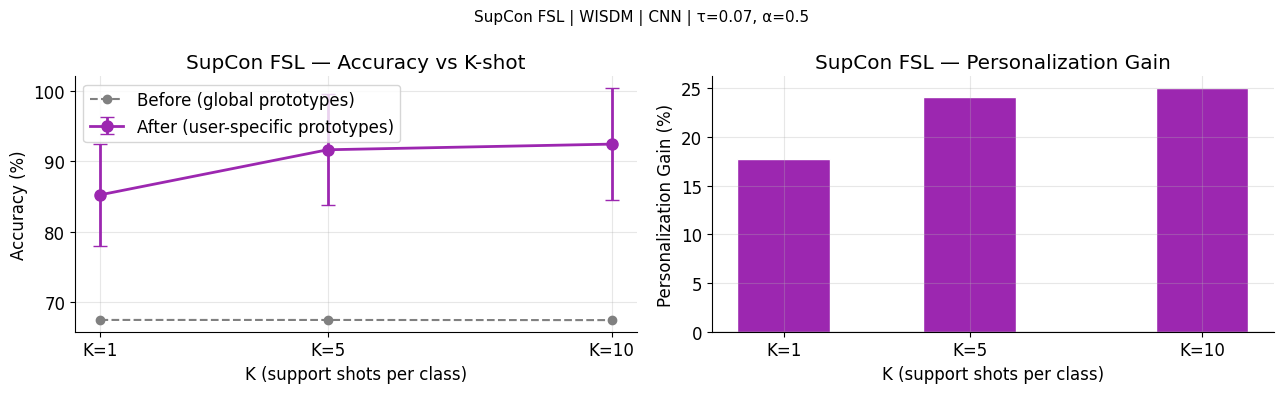

Saved: /content/drive/MyDrive/fsl_har_checkpoints/wisdm/cnn/supcon/kshot_curves.png


In [ ]:
print('── SupCon Personalization Gain Summary ──')
print(f'{"K-shot":>8} {"Acc Before":>12} {"Acc After":>12} {"Gain":>10} {"CI95":>10}')
print('─' * 58)

all_summary_results = []

for k in K_SHOTS:
    if not supcon_results[k]:
        continue

    accs_before = [r['acc_before_mean'] for r in supcon_results[k]]
    accs_after  = [r['acc_after_mean']  for r in supcon_results[k]]
    gains       = [r['gain']            for r in supcon_results[k]]

    ab   = float(np.mean(accs_before))
    aa   = float(np.mean(accs_after))
    gain = float(np.mean(gains))
    ci95 = float(1.96 * np.std(gains) / np.sqrt(len(gains)))

    print(
        f'{k:>8}-shot '
        f'{ab*100:>10.2f}% '
        f'{aa*100:>10.2f}% '
        f'{gain*100:>+9.2f}% '
        f'{ci95*100:>8.2f}%'
    )

    result = {
        'dataset'     : DATASET_NAME,
        'backbone'    : BACKBONE_TYPE,
        'method'      : 'supcon',
        'k_shot'      : k,
        'seed'        : MASTER_SEED,
        'acc_before'  : ab,
        'acc_after'   : aa,
        'gain'        : gain,
        'ci95'        : ci95,
        'temperature' : SUPCON_TEMP,
        'alpha'       : SUPCON_ALPHA,
        'n_test_users': len(supcon_results[k]),
    }
    config_key = make_config_key(DATASET_NAME, BACKBONE_TYPE, 'supcon', k, MASTER_SEED)
    mark_completed(config_key, result)
    all_summary_results.append(result)

print(f'\n✅ Results saved to registry')

# ─── K-shot curves ────────────────────────────────────────────────────────────
if all_summary_results:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ks          = [r['k_shot']     for r in all_summary_results]
    accs_before = [r['acc_before'] for r in all_summary_results]
    accs_after  = [r['acc_after']  for r in all_summary_results]
    gains       = [r['gain']       for r in all_summary_results]
    ci95s       = [r['ci95']       for r in all_summary_results]

    axes[0].plot(ks, [a*100 for a in accs_before], 'o--',
                 color='gray', label='Before (global prototypes)', linewidth=1.5)
    axes[0].errorbar(
        ks, [a*100 for a in accs_after],
        yerr=[c*100 for c in ci95s],
        fmt='o-', color=METHOD_COLORS['supcon'],
        label='After (user-specific prototypes)',
        linewidth=2, capsize=5, markersize=8
    )
    axes[0].set_xticks(ks)
    axes[0].set_xlabel('K (support shots per class)')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_title('SupCon FSL — Accuracy vs K-shot')
    axes[0].legend()

    bar_colors = [METHOD_COLORS['supcon'] if g >= 0 else '#FF5722' for g in gains]
    axes[1].bar(ks, [g*100 for g in gains], color=bar_colors, edgecolor='white', width=2)
    axes[1].axhline(y=0, color='black', linewidth=0.8)
    axes[1].set_xticks(ks)
    axes[1].set_xlabel('K (support shots per class)')
    axes[1].set_ylabel('Personalization Gain (%)')
    axes[1].set_title('SupCon FSL — Personalization Gain')

    for ax in axes:
        ax.set_xticklabels([f'K={k}' for k in ks])

    fig.suptitle(
        f'SupCon FSL | {DATASET_NAME.upper()} | {BACKBONE_TYPE.upper()} | '
        f'τ={SUPCON_TEMP}, α={SUPCON_ALPHA}',
        fontsize=11
    )
    plt.tight_layout()
    plot_path = os.path.join(fsl_ckpt_dir, 'kshot_curves.png')
    plt.savefig(plot_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved: {plot_path}')

## Cell 12 — Embedding Space Visualisation (t-SNE)

Visualise how well the contrastive training separates activity classes.  
A good SupCon embedding shows tight intra-class clusters with clear margins between classes.  
This is a strong thesis figure.

Computing t-SNE of test user embeddings...
   Embedding array : (2000, 128)
   Running t-SNE...


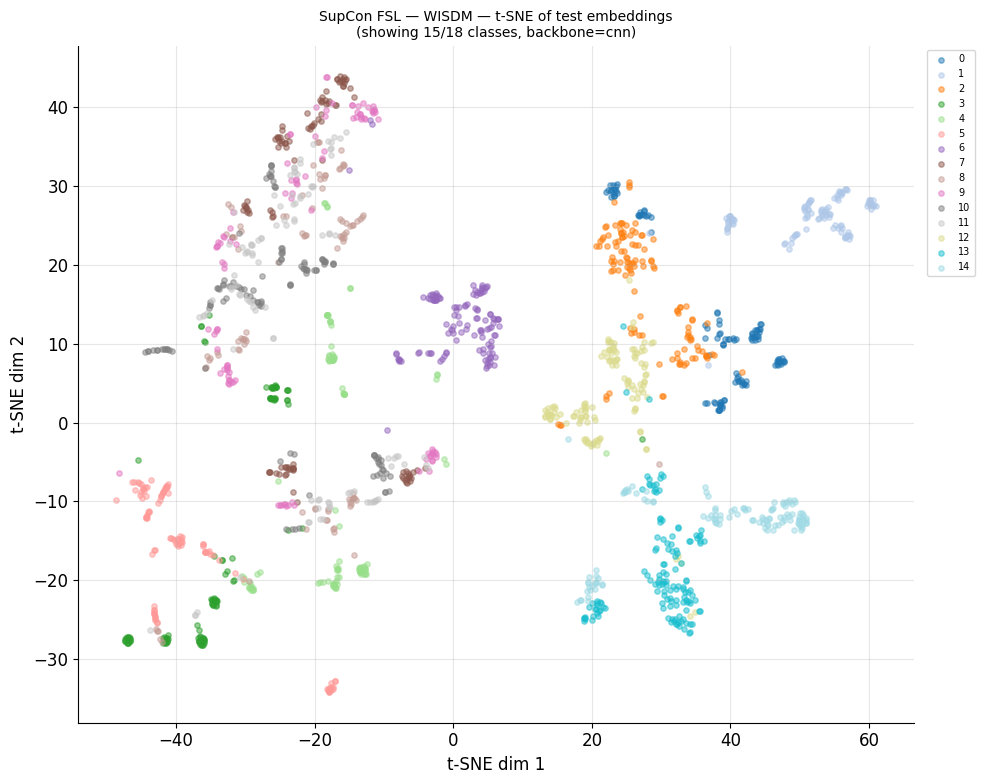

Saved: /content/drive/MyDrive/fsl_har_checkpoints/wisdm/cnn/supcon/tsne_embeddings.png

Note: tight clusters with clear margins = good contrastive training
      overlapping clusters = embedding space needs improvement


In [ ]:
from sklearn.manifold import TSNE

# Collect embeddings from test users
print('Computing t-SNE of test user embeddings...')

best_backbone.eval()
all_embs   = []
all_labels = []

with torch.no_grad():
    indices = np.where(test_mask)[0]
    # Subsample for speed — max 2000 windows
    if len(indices) > 2000:
        rng_tsne = np.random.default_rng(MASTER_SEED)
        indices  = rng_tsne.choice(indices, 2000, replace=False)

    for start in range(0, len(indices), 256):
        batch_idx = indices[start:start + 256]
        stream_list = [
            torch.tensor(streams[s][batch_idx], dtype=torch.float32).to(DEVICE)
            for s in stream_names
        ]
        emb = best_backbone.get_embedding(stream_list)
        all_embs.append(emb.cpu().numpy())
        all_labels.extend(y[batch_idx].tolist())

all_embs   = np.concatenate(all_embs, axis=0)
all_labels = np.array(all_labels)

print(f'   Embedding array : {all_embs.shape}')
print(f'   Running t-SNE...')

tsne = TSNE(n_components=2, perplexity=30, random_state=MASTER_SEED, n_iter=1000)
embs_2d = tsne.fit_transform(all_embs)

# Plot — colour by class, show only first 15 classes for clarity
n_show      = min(15, n_classes)
show_labels = list(range(n_show))
mask_show   = np.isin(all_labels, show_labels)

fig, ax = plt.subplots(figsize=(10, 8))
cmap    = plt.cm.get_cmap('tab20', n_show)

for i, c in enumerate(show_labels):
    m   = (all_labels == c) & mask_show
    lbl = cfg['activity_labels'].get(c, str(c)) if hasattr(cfg.get('activity_labels'), 'get') else str(c)
    if m.sum() > 0:
        ax.scatter(
            embs_2d[m, 0], embs_2d[m, 1],
            c=[cmap(i)], label=str(lbl)[:15],
            alpha=0.5, s=15,
        )

ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7, ncol=1)
ax.set_title(
    f'SupCon FSL — {DATASET_NAME.upper()} — t-SNE of test embeddings\n'
    f'(showing {n_show}/{n_classes} classes, backbone={BACKBONE_TYPE})',
    fontsize=10
)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()

tsne_path = os.path.join(fsl_ckpt_dir, 'tsne_embeddings.png')
plt.savefig(tsne_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {tsne_path}')
print(f'\nNote: tight clusters with clear margins = good contrastive training')
print(f'      overlapping clusters = embedding space needs improvement')

## Cell 13 — Final Summary

In [ ]:
print('=' * 65)
print('  SUPERVISED CONTRASTIVE FSL COMPLETE')
print('=' * 65)
print(f'  Dataset          : {DATASET_NAME}')
print(f'  Backbone         : {BACKBONE_TYPE}')
print(f'  Temperature τ    : {SUPCON_TEMP}')
print(f'  Spread α         : {SUPCON_ALPHA}')
print(f'  Proj dim         : {PROJ_DIM}')
print(f'  Epochs trained   : {epochs_ran}')
print(f'  Best val loss    : {best_val_loss:.4f}')
print()
print(f'  Results:')
print(f'  {"K":>4}  {"Before":>8}  {"After":>8}  {"Gain":>8}  {"CI95":>8}')
print(f'  {"-"*46}')
for r in all_summary_results:
    print(
        f'  {r["k_shot"]:>4}  '
        f'{r["acc_before"]*100:>7.2f}%  '
        f'{r["acc_after"]*100:>7.2f}%  '
        f'{r["gain"]*100:>+7.2f}%  '
        f'±{r["ci95"]*100:>5.2f}%'
    )
print('=' * 65)
print()
print('  SupCon note:')
print('  Projection head discarded after training (standard practice).')
print('  Evaluation uses backbone embedding directly.')
print('  Training is batch-based, not episodic.')
print()
print('  ALL 4 FSL METHODS COMPLETE FOR THIS CONFIG')
print()
print('  Next steps:')
print('  Phase 3: Re-run notebooks 08-11 with lstm and transformer backbones')
print('  Phase 4: Re-run notebooks 01-11 with other 3 datasets')
print('  Phase 5: Notebook 14 (experiment runner) automates all of this')
print('=' * 65)

  SUPERVISED CONTRASTIVE FSL COMPLETE
  Dataset          : wisdm
  Backbone         : cnn
  Temperature τ    : 0.07
  Spread α         : 0.5
  Proj dim         : 64
  Epochs trained   : 16
  Best val loss    : 4.1551

  Results:
     K    Before     After      Gain      CI95
  ----------------------------------------------
     1    67.50%    85.25%   +17.76%  ± 7.24%
     5    67.49%    91.64%   +24.15%  ± 7.90%
    10    67.47%    92.44%   +24.97%  ± 7.97%

  SupCon note:
  Projection head discarded after training (standard practice).
  Evaluation uses backbone embedding directly.
  Training is batch-based, not episodic.

  ALL 4 FSL METHODS COMPLETE FOR THIS CONFIG

  Next steps:
  Phase 3: Re-run notebooks 08-11 with lstm and transformer backbones
  Phase 4: Re-run notebooks 01-11 with other 3 datasets
  Phase 5: Notebook 14 (experiment runner) automates all of this
